# Feature analysis — `mid_rate_surge`

This notebook follows the project's feature-analysis **method** (the current cross-venue-gap
template) on a new feature: **`mid_rate_surge`** — a fast/slow ratio of a venue's **mid-update rate**.
The text says what to do and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and
**byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best buy and
best sell quote.) The next section recaps the model these features feed.

**The feature, in one line.** A venue's **mid-update rate** is how often *that venue's* mid *changes*,
per second. Smooth that rate two ways — a **fast** EMA and a **slow** EMA — and take the ratio:

`mid_rate_surge(ex; fast, slow) = EMA_fast(ex mid-update-rate) / EMA_slow(ex mid-update-rate)`

A ratio above 1 means that venue is quoting/repricing *faster than usual* right now — a quoting-activity
**surge**; below 1, a lull. The hypothesis is that a surge **predicts intensity**: when a venue starts
repricing quickly, more byb mid-moves are about to follow.

**This is a per-exchange feature (like the template's dislocation gap).** Exactly as the template's gap
feature computes a value for *each* non-byb venue, we compute a surge for **each** venue —
byb, okx **and** bin — each from that venue's OWN mid-moves, and ask whether it predicts **byb's** next
move. The byb leg is the *target's own* tempo; the okx/bin legs are **cross-venue** quoting-tempo
lead/lag.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a production-style streaming build reproduces the feature on real data,
  so the code really computes what we think it does (**for every per-exchange leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

Everything after that decides *which part of the model* the feature feeds, and *at what time-scale* —
and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is
not ship-done.

> **Control-circularity caveat (read this first — and note it is now PER LEG).** byb's mid-update
> *rate* is exactly the quantity the model's **rate yardstick `λ_ev`** measures, so **byb's own**
> `mid_rate_surge` leg is essentially **`rate_momentum`, one of the §5 controls**, built as its own
> family — it is *not* expected to add much *over the rate control*. **But the okx/bin legs are NOT
> circular** with byb's controls: they are *another venue's* quoting tempo, and they genuinely test
> cross-venue lead/lag. So the honest question splits per leg: the byb leg's value (if any) is span
> tuning over the control; the okx/bin legs' value (if any) is **new cross-venue information**. This is
> why `mid_rate_surge` is a **control**-kind feature (a regime descriptor), judged on its **standalone**
> signal for the own leg and a **marginal lead** test for the cross-venue legs. §6/§9 quantify each,
> straight.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what the
model does. We forecast how byb's mid-price moves over the next ~100 ms, split into two simpler
questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed* move
(direction *and* size, together), in units of byb's recent **volatility** — the **volatility
yardstick** `σ_ev` (the exp-weighted RMS of byb's *actual* mid-moves)? Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet ones few.
This head predicts the *count* of moves over the next 100 ms, measured against the recent pace — the
**rate yardstick** `λ_ev` — so its target is `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only. Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`) but
**updated between trades**. `λ_ev` is byb's **mid-moves per second** = the exp-weighted byb move-count
`W` ÷ the exp-weighted seconds-per-trade. **`mid_rate_surge` is built from exactly the same `W / dt`
rate machinery — per venue, at two spans, as a ratio.** That is the whole point of the caveat above: the
raw atom of the *byb* leg *is* the rate the rate yardstick measures; the okx/bin legs are the same atom
for *other* venues.

**Why split into two heads?** A move over a window is *how many* little moves times *how big* each one
is. Pulling "how many" (rate) apart from "how big" (price) lets each head learn a steadier thing. This
"how many × how big" split is the classic **subordination** model of asset prices (Clark, 1973; Ané &
Geman, 2000): returns over fixed clock-time look messy but become well-behaved once you condition on the
*number* of events. `mid_rate_surge` is squarely a **how-many** feature — it speaks to the rate head.

Two diagnostics recur below: does a feature's *signed* value predict the move (price head), and does its
*magnitude* predict how many moves come (rate head)? The model is fed the **signed** feature for *both*
heads; the rate head learns the magnitude itself. For `mid_rate_surge` we expect the rate head to be
where it lives, if anywhere.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build the
  feature the same way for **every** venue and keep them all. (Here that is literal: byb, okx and bin
  each get their own surge leg; the okx/bin legs are exactly the "does another venue lead byb?" test.)
- **Don't pick "the best exchange"** by average score — that throws away the moments another venue
  leads. Keep all; let the model weight them.
- **Don't pool exchanges by default.** Check per-exchange vs single vs pooled across time-scales (§9).
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — *especially for
  the byb leg*, which is a near-twin of the rate control and could be re-reporting it.
- **Don't ship a feature without the §4 parity check** — a production-style build matching the
  vectorized version on real data, for **every** per-exchange leg.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't normalize reflexively.** `mid_rate_surge` is a **ratio of two rates** — already
  dimensionless and comparable across calm/busy markets — so it needs **no** yardstick division.
- **Don't over-transform for the network.** Pick the lightest reshaping that works (§8).

**Do**
- **Do start with a falsifiable hypothesis** — a surge in a venue's repricing tempo precedes more byb
  mid-moves. Disproof: no link to the forward move-count at any time-scale (or, for the byb leg, it's
  fully explained by the rate control; for okx/bin, no cross-venue marginal).
- **Do make every average a trade-tick EMA.** *Every* smoother — every venue's rate legs, `σ_ev`,
  `λ_ev` — is an exponential moving average **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet
  **updated on every relevant event between trades** (a venue's mid-move injects; the clock decays on a
  trade), never a wall-clock or boxcar window. O(1) state, bit-identical online vs offline.
- **Do read a sparse flow as `E / W` on the shared clock.** Each venue's mid-moves are present on only
  *some* events; the rate's numerator is that venue's exp-weighted move count `W`, decayed every trade
  on the **one** shared clock, injected only on **that venue's** move, read live. The `E/W` form makes a
  merged-clock EMA approximate that venue's **own**-clock EMA at a rescaled span — so we get genuine
  per-venue rates from one clock (tight at large spans, fraying at small spans where cross-venue lead/lag
  lives — exactly the regime §9 probes).
- **Do treat all records sharing a timestamp as ONE event.** The decay clock advances **once** per
  trade-timestamp; a venue's N simultaneous prints are one event, at most one mid-move.
- **Do test against both heads — but feed both the *signed* feature.** The magnitude→intensity
  (rate-head) check is the one that matters; the price-head check is a diagnostic we expect to be weak.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future).
- **Do treat a feature as a family across time-scales** and sweep the WHOLE fast×slow grid, per venue.
- **Do prove regime-invariance with Gate A — never assume it.** A surge ratio *should* be scale-stable
  and not track the regime level, but **measure** it (§6) — a level in disguise fails Gate A. And because
  `mid_rate_surge` is itself a regime descriptor, judge its *signal* on the **standalone** (own leg) /
  **cross-venue marginal** (okx/bin) basis, never marginal-over-its-own-control (that's circular).

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a venue's mid-update **rate** (mid-moves per second), smoothed fast vs slow, as a **ratio** — one per venue (byb, okx, bin) |
| **feeds** | the **rate head** (intensity: how many byb moves next) is the natural home; price-head is a diagnostic |
| **predicts** | byb's 100 ms move-count (and, weakly if at all, direction) |

**The idea.** Count how often a venue's mid *changes*. Express it as a rate — moves per second — using
the exact `W / dt` form the rate yardstick uses. Smooth that rate two ways (a *fast* EMA, a *slow* EMA)
and divide: `surge = rate_fast / rate_slow`. Above 1 = that venue is repricing faster than its recent
baseline; below 1 = slower. **Do this for byb, okx and bin** — the byb leg is the target's own tempo,
the okx/bin legs are other venues' tempo.

**Why it should work.** Quoting activity clusters. When market-makers start repricing a venue quickly —
news, an inventory shock, a cross-venue move propagating in — the elevated tempo persists for tens to
hundreds of milliseconds, so a fresh **surge** forecasts a **burst** of upcoming byb mid-moves. For the
**cross-venue** legs there is an extra mechanism: if okx (or bin) starts repricing first, that tempo can
**lead** byb's by a beat — the classic no-fixed-leader lead/lag the template warns about. That is an
*intensity* statement: it speaks to *how many* moves, not *which way* — so the **rate head**.

**Why the byb leg might NOT add (the caveat, quantified later).** byb's mid-update rate **is** `λ_ev`. A
fast/slow ratio of it **is** rate momentum — one of the §5 controls. So byb's own leg risks being a
re-parameterised control with little *marginal* value over `rate_momentum`. **The okx/bin legs carry no
such circularity** — they are other venues' rates, not byb's control — so their marginal, if positive, is
genuinely new cross-venue information. §6/§9 measure each leg straight. (This is also why
`FEATURE_KIND = "control"` below: a regime descriptor judged on its standalone / cross-venue signal.)

**What would disprove it.** No link to the forward byb move-count at any (fast, slow) for any venue; the
byb leg's link vanishing once we control for `rate_momentum`/`rate_level` (it *was* the rate control); or
the okx/bin legs adding ≈0 over byb's controls (cross-venue tempo carries nothing byb's own doesn't).

> **No fixed leader.** Built the same way for every venue, all kept. The okx/bin legs are precisely the
> "another venue might lead" test; the trade clock pools all three venues' trades (the shared "tick").

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every relevant event in between**, so a read between
trades is never stale. For each venue's `mid_rate_surge` the moving parts are:

- **The move-count numerator `W_ex`** — a **sparse flow** (venue `ex` moves on only *some* events). It
  is an EMA that **decays every trade** (on the shared clock) and **injects `1` on every `ex` mid-move**,
  read **live**. This is the same `E/W`-style flow the yardsticks use, read at the anchor so the count
  reflects every move since the last trade. Per the merged-clock↔own-clock equivalence, dividing through
  by the common decay makes this a *per-venue* rate even though all venues share one clock.
- **The seconds-per-trade denominator `dt`** — a **per-trade** EMA of the gap between consecutive
  trade-timestamps, held flat between trades. This is a property of the **shared clock**, so it is the
  same for every venue; the per-venue content lives entirely in `W_ex`.

So `rate_ex(span) = W_ex(span) / dt(span)` = venue `ex`'s mid-moves per second at that span, and the
feature is `rate_ex(fast) / rate_ex(slow)`. Both spans share the one trade clock; the **ratio** cancels
the warm-up and the common decay factor — no yardstick division needed. (Because `dt` cancels too, the
surge divides by **no** yardstick of either head's target — that is why `STRAT_VAR = None` in §5.)

The trap the template warns about (push a `0` on a non-move and "per move" silently becomes "per trade")
applies here too: `W_ex` must inject **only** on a real `ex` mid-move, and **once** per timestamp
(simultaneous prints are one event). The §4 parity check re-derives all of this from raw events, per
venue, and confirms it bit-exact.

## 2. The exact definition

A definition has to get three things right.

**Causal** — only data up to the moment it's computed; no peeking. (A stray forward-fill is the usual
accidental break.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than
clock-seconds. A venue's mid-moves between trades update what the EMA *reads* but do **not** advance the
clock; only a trade decays the EMAs once.

**Comparable across calm and wild markets** — and here it already is: `mid_rate_surge` is a **ratio of
two rates**, so the absolute pace cancels. **No `σ_ev` / `λ_ev` division** is applied to the feature. The
yardsticks still appear — to build the §5 controls and the rate-head *target* — but not inside the
feature.

Put it together, **for each venue `ex`**:

**2a — The shape** (the whole idea, in one line):

`mid_rate_surge(ex) = rate_ex,fast / rate_ex,slow`,  where  `rate_ex(N) = W_ex(N) / dt(N)` = ex mid-moves/sec.

A fresh acceleration on venue `ex` shows up as its fast rate pulling above its slow one (ratio > 1).

**2b — The EMAs we use, and how they update:**

- **`W_ex(N)`** (per-venue move-count numerator) — a **sparse flow**: decay once per trade-timestamp on
  the shared clock (`α=2/(N+1)`), inject `1` on each real `ex` mid-move, read **live** at the anchor.
- **`dt(N)`** (seconds-per-trade denominator) — a **per-trade** EMA of `Δ(trade timestamp)/1e9`, held
  flat between trades; a property of the shared clock (same for all venues).
- **`σ_ev`, `λ_ev`** (yardsticks, span `YARDSTICK_N`) — used only for the controls and the rate-head
  target: `σ_ev = √(E/W)` over **byb** moves; `λ_ev = W_byb / dt` at `YARDSTICK_N` (note: `λ_ev` is
  literally `rate_byb(YARDSTICK_N)` — the byb leg's own rate at the yardstick span, the caveat in code).

§3 builds exactly this; §4 re-derives it from raw events, per venue, and confirms it bit-exact. The cell
below loads the data, builds the shared trade clock, computes each venue's mid-move stream, and computes
both yardsticks (from byb) as `E/W` / `W÷dt` flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we PREDICT; byb mid also feeds σ_ev/λ_ev & the targets
EXCHANGES   = ["byb", "okx", "bin"]              # EVERY venue gets its own mid-rate surge leg (byb = circular self-leg; okx/bin = cross-venue)
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}  # byb/okx mid = merged (trade-fused); bin = front_levels (merged blocked for bin perp)
FAST        = [1, 3, 10, 30, 100, 300]          # fast-rate EMA spans — the WHOLE family swept (1 = no smoothing of the rate)
SLOW        = [30, 100, 300, 1000, 3000, 10000] # slow-rate EMA spans (each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): trade-tick EMA α=2/(N+1)
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order); EVERY venue's mid now drives its own surge leg.
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9 # seconds between consecutive trades (shared clock; same dt for every venue)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# per-venue mid-move stream: collapse each venue's mid to ONE update per timestamp; a REAL move is where the mid changed.
def move_stream(ex):
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])          # collapse same-TIMESTAMP rows to the final mid (one event)
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)  # this venue's log-return per timestamp
    mv = blr != 0.0                                              # a REAL mid-MOVE: one per timestamp where the mid changed
    return rx, mid, blr, mv
MV = {}                                                          # per venue: move times, squared returns, cumulative count
for ex in EXCHANGES:
    rx, mid, blr, mv = move_stream(ex)
    MV[ex] = dict(rx=rx, mid=mid, blr=blr, mv_rx=rx[mv], mv_r2=blr[mv] ** 2,
                  cum=np.concatenate([[0.0], np.cumsum(mv.astype(float))]))
byb_rx, byb_mid = MV["byb"]["rx"], MV["byb"]["mid"]              # byb's stream backs σ_ev/λ_ev and the prediction targets

def _ewma(x, span):                                                # per-trade EMA (seconds/trade leg; shared clock)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(mv_rx, val, anchors, span):    # live EWMA of `val` over A VENUE'S move stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def mid_rate(ex, anchors, span):            # venue ex's mid-update RATE at a span: live move-count W ÷ shared seconds dt = moves/sec
    w  = _flow_at(MV[ex]["mv_rx"], np.ones(MV[ex]["mv_rx"].size), anchors, span)   # W_ex: exp-weighted ex-move count (live at anchor)
    dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]     # seconds/trade (shared clock, held flat between trades)
    return w / np.maximum(dt, 1e-12)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev from BYB — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(MV["byb"]["mv_rx"], MV["byb"]["mv_r2"], anchors, span)         # E: exp-weighted squared byb moves
    e_mv = _flow_at(MV["byb"]["mv_rx"], np.ones(MV["byb"]["mv_rx"].size), anchors, span)  # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]   # seconds/trade
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second  (== mid_rate('byb', ·, span))
    return sig, lam
print(f"per-venue move counts:  " + "  ".join(f"{ex}={MV[ex]['mv_rx'].size:,}" for ex in EXCHANGES))
print(f"yardsticks (from byb): decay span {YARDSTICK_N} trades; λ_ev == mid_rate('byb', ·, YARDSTICK_N) — the caveat in code form")

trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


per-venue move counts:  byb=147,238  okx=128,848  bin=179,338
yardsticks (from byb): decay span 10000 trades; λ_ev == mid_rate('byb', ·, YARDSTICK_N) — the caveat in code form


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a streaming
version that does constant work per trade (no growing buffers). They have to agree, which §4 checks.

We lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent 100 ms
outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly why §5's
walk-forward gate uses an embargo), read byb's actual move and move-count over the next 100 ms (the
things we're predicting), and compute the feature **per venue** at each grid point.

In [2]:
# evaluation grid (causal) + forward targets
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # enough trades for the slowest EMA/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this rate feature): byb's 100 ms return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # price-head target (σ-units)

def mid_rate_surge(ex, n_fast, n_slow):     # THE FEATURE, per venue: ratio of venue ex's mid-update rate, fast span over slow span
    rf = mid_rate(ex, anchor_ts, n_fast)                          # fast rate (moves/sec)
    rs = mid_rate(ex, anchor_ts, n_slow)                          # slow rate (baseline tempo)
    return rf / np.maximum(rs, 1e-12)                             # >1 = surging faster than baseline; <1 = lull
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    demo = mid_rate_surge(ex, 10, 1000)
    print(f"  mid_rate_surge({ex},10,1000): median {np.nanmedian(demo):.3f}  p10 {np.nanpercentile(demo,10):.3f}  p90 {np.nanpercentile(demo,90):.3f}")

σ_ev median 2.78e-05,  λ_ev median 1.18 moves/s


grid: 1,706,369 anchors


  mid_rate_surge(byb,10,1000): median 0.052  p10 0.000  p90 3.118


  mid_rate_surge(okx,10,1000): median 0.006  p10 0.000  p90 1.773


  mid_rate_surge(bin,10,1000): median 0.003  p10 0.000  p90 1.060


## 4. Check the code is right — a parity check (a production-style streaming build)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two agree on real
data, **bit-exact**, **for every per-exchange leg** — a **parity check**. The streaming build is the
**production** reference: an O(1) state machine you push **raw events** into and read `value(ex, fast,
slow)` from. State is a few scalar EMAs per venue — no buffers, no history, independent of how long it
runs.

This is a different *code path* from §3 (no `lfilter`, no `_flow_at`) but it runs the **actual production
online EMAs** — `boba.ema`'s tested classes, the same objects the live system would use — so §4 validates the
production code, not a throwaway re-implementation. Each EMA is one of those classes:

- **`W_ex` (move count), per venue per span** — a **`KernelMeanEMA`** over that venue's mid-moves: `add(1.0)`
  on each real `ex` mid-move (so `E` and the weight `W` both accumulate the move count), and `tick()` once per
  trade-timestamp to decay it. The move-count mass is the EMA's own `W` accumulator (`= Σ α(1−α)^j` over moves,
  decayed on the shared trade clock), read live at the anchor.
- **`dt` (seconds/trade), per span** — one **`KernelMeanEMA`** per span (shared across venues): `add(gap)`
  with the seconds since the previous trade and `tick()` once per trade, read as its `E/W` mean (a plain
  per-trade mean of the gap — `W` is the count mass), held flat between trades.
- **rate_ex = W_ex / dt** (the move-count mass over the seconds-per-trade EMA — exactly `λ_ev`'s `W / E[Δt]`
  shape, per venue per span), and **value(ex) = rate_ex,fast / rate_ex,slow**.

**Driver discipline (matches the trade clock):** apply every record at a timestamp, then `refresh()`
once — detect **each venue's** mid-move and inject its `W`, advance the clock (decay every `W`, and
`tick()`+`add(gap)` every `dt`) **at most once**, and only if a trade landed. A book-only instant moves a venue's mid
(maybe a move → inject) without advancing the clock. We feed the **whole raw stream** — every venue's
book updates and trades — into **one** builder and read **every venue's** feature at each grid anchor.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # E/W flow mean: each venue's move-count W AND the shared seconds-per-trade flow dt, src/boba/ema.py

class LiveMidRateSurge:
    # Pure feature state machine for per-venue mid-update-rate surges. O(1), all scalar — no buffers, no history.
    # Per venue per span we hold W_ex = a KernelMeanEMA over that venue's mid-moves (add(1.0) on each move, tick() each
    # trade); the move-count mass is its own W accumulator. Per span we hold ONE dt = a KernelMeanEMA of seconds-per-trade
    # (the shared clock; add(gap) on each trade, tick() each trade, read E/W). rate_ex = W_ex/dt; feature = rate_ex,fast/rate_ex,slow.
    # State keyed by full listing so a perp
    # and spot never collide. Each venue's mid is built INSIDE (merged venues fuse trades by newest-exchange-time; book-only
    # venues take the latest snapshot). The driver applies all records at a timestamp, then calls refresh() once: detect
    # EACH venue's mid-move and inject its W (add), then advance the clock AT MOST ONCE — tick every W, tick+add every dt —
    # only if a trade landed.
    def __init__(self, venues, spans, fuse_trades):
        self.venues = list(venues)                                         # full listings we track a surge for (byb,okx,bin)
        self.spans = list(spans)                                           # all distinct EMA spans we need (fast+slow)
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.W = {v: {N: KernelMeanEMA(N) for N in self.spans} for v in self.venues}  # move-count flow per venue per span (read its W mass)
        self.dt = {N: KernelMeanEMA(N) for N in self.spans}                # seconds-per-trade flow EMA per span (shared clock; E/W read)
        self.prev = {v: None for v in self.venues}                         # each venue's last log-mid, to detect a real move
        self.prev_ts = None                                                # last trade-timestamp (for the dt gap)
        self.was_trade_present = False                                     # did a trade land this timestamp?

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self, ts):                                                # ONE per TIMESTAMP
        traded, self.was_trade_present = self.was_trade_present, False
        for v in self.venues:                                            # detect EACH venue's mid-move -> inject its count mass live (before any decay)
            m = self._mid(v)
            if m is None: continue
            lm = math.log(m)
            if self.prev[v] is not None and lm != self.prev[v]:
                for N in self.spans: self.W[v][N].add(1.0)               # KernelMeanEMA.add(1.0): E,W += α·1 — the move-count flow
            self.prev[v] = lm
        if traded:                                                        # a trade landed -> advance the clock exactly once
            gap = 0.0 if self.prev_ts is None else (ts - self.prev_ts) / 1e9
            for N in self.spans:
                for v in self.venues: self.W[v][N].tick()                # decay every venue's move-count flow one trade-tick (E,W *= 1-α)
                self.dt[N].tick(); self.dt[N].add(gap)                    # decay then inject this trade's gap into the seconds-per-trade flow (E/W = the trade-tick EMA)
            self.prev_ts = ts

    def on_book(self, listing, t, bid, ask):
        if listing in self.fuse_trades:
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True

    def _rate(self, v, N):
        d = self.dt[N].value()
        if d is None or not (d > 1e-12): return float("nan")
        return self.W[v][N].W / d                                        # move-count mass (the KernelMeanEMA's W accumulator) ÷ seconds-per-trade

    def value(self, v, n_fast, n_slow):                                   # the feature for venue v: rate_fast / rate_slow
        rf, rs = self._rate(v, n_fast), self._rate(v, n_slow)
        if not (rs > 1e-12): return float("nan")
        return rf / rs

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 10, 1000, 40_000                  # validate ONE (fast,slow) pair, for ALL THREE venues, over the first ~N_GRID grid points
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept <= cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time)
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (fed as bid=ask=mid); now its OWN surge leg too
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points...")

# --- the CALLER drives it: apply each timestamp's events, refresh() once, READ value() for EVERY venue at every grid anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
VENUES = [f"{ex}_{COIN}" for ex in EXCHANGES]
feat = LiveMidRateSurge(VENUES, sorted({NF, NS}), fuse)
na = min(N_GRID, len(anchor_ts))
stream = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: stream[ex][ai] = feat.value(f"{ex}_{COIN}", NF, NS)
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp)
        if kindL[i] == 0: feat.on_book(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        else:             feat.on_trade(LISTINGS[lidL[i]], tL[i], aL[i], bL[i])
        i += 1
    feat.refresh(rx)                               # apply the timestamp: inject each venue's W on its move, advance the clock once if a trade landed
while ai < na:
    for ex in EXCHANGES: stream[ex][ai] = feat.value(f"{ex}_{COIN}", NF, NS)
    ai += 1

# --- one raw-event stream -> three per-venue features: check EACH leg against its §3 vectorized feature, bit-exact ---
print(f"one raw-event stream -> per-venue surge legs, vs the vectorized build (Nf={NF}, Ns={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = mid_rate_surge(ex, NF, NS)[:na]
    both = np.isfinite(stream[ex]) & np.isfinite(ref)
    diff = np.abs(stream[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"streaming build does not reproduce the {ex} feature"
print(f"parity: the raw-event streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| {worst:.2e})")

streaming 3,211,783 raw events (book + trades, all venues) over ~40,000 grid points...


one raw-event stream -> per-venue surge legs, vs the vectorized build (Nf=10, Ns=1000):


  byb:  max |diff| 4.75e-12  on 40,000 grid points


  okx:  max |diff| 8.24e-12  on 40,000 grid points


  bin:  max |diff| 1.05e-11  on 40,000 grid points
parity: the raw-event streaming build reproduces ALL THREE per-venue legs  OK  (worst |diff| 1.05e-11)


**Conclusion.** From one stream of ~3.2 M raw events the streaming O(1) builder reproduces **every**
venue's vectorized feature to floating-point precision — **worst max |diff| ≈ 1.1e-11** over 40,000 grid
points per leg, pure last-digit round-off from the recursive EMAs, far under the `1e-6` bar. The streaming
build runs the **actual production online EMAs** — `boba.ema`'s `KernelMeanEMA` for **both** legs (each
venue's move-count flow, and the shared seconds-per-trade flow read as `E/W`), ticked/added event-by-event
— while §3 vectorizes the *same* recursion offline via `lfilter`/`_flow_at` (a genuinely different code path). Agreement means each
leg computes what we claim: that **venue's** live mid-update rate (move-count mass ÷ shared seconds-per-trade)
at two spans, ratioed. The byb, okx and bin legs all match, so the §3 per-venue build is trustworthy. (The
check runs at one (fast, slow) pair; the recursion is identical for every span, so this validates the family.)

## 5. Is the signal real? — the hygiene gates (and the per-leg circularity reckoning)

A correlation is an easy way to fool yourself — and **the risk is acute for the byb leg**, a near-twin of
the rate control. The gates are **two independent tests** (see the Gate A / Gate B box in §6): **(A)** is
the feature **regime-invariant** — a stable distribution that doesn't leak the vol/rate state — and
**(B)** does it **predict** something the market's current state doesn't already tell us? The only
**controls** for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, expanding-window walk-forward**: each fold trains only
on the *past*, leaves an **embargo gap** sized to clear the 100 ms outcome windows with margin. Note the
embargo does **not** fully decorrelate the slow EMA/yardstick features: their memory is ≈ `YARDSTICK_N` /
(trades-per-sec) — longer than the ~100 s embargo — so re-check this if you slow the spans. We also report
the **per-fold** ICs and a **block-bootstrap 90% CI** so the headline respects the autocorrelation.

**The reckoning to watch — now per leg.** `rate_momentum = log(λ_fast / λ_slow)` is itself a fast/slow
ratio of **byb's** rate — *structurally the same object as the **byb** `mid_rate_surge` leg*. Because
`mid_rate_surge` *is* a regime descriptor, `FEATURE_KIND = "control"`: marginal-over-its-own-control is
circular, so the **byb own leg** is judged on its **standalone** signal (`own=True`), while the **okx/bin
cross-venue legs** stay a **marginal lead** test over the controls (`own=False`) — any marginal they show
is genuine cross-venue information. We never hide the byb-leg circularity.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent rate vs slower rate — the NEAR-TWIN of the byb surge leg

# rate-head target = byb moves in the next 100 ms, divided by λ_ev (the rate yardstick) — the head this feature serves
fwd_count = (MV["byb"]["cum"][np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - MV["byb"]["cum"][np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics/SURGES) -> itself a valid feature, but it
# OVERLAPS the controls, so its OWN leg is judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "control"                                               # mid_rate_surge = a move-RATE surge -> a regime descriptor, not an alpha
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
levels = [rate_level, vol_level]                                       # the regime COORDINATE — used only for the §6 leak re-check, NEVER as a Gate B control.
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target when the feature is a control RATIO dividing by it (count/λ_ev clone
                                                                       # -> lam_at_anchor; σ_ev thing on the σ_ev target -> sigma_at_anchor). mid_rate_surge is rate_fast/rate_slow,
                                                                       # and rate = W/dt, so BOTH the dt and the λ_ev scale CANCEL in the ratio — the surge divides by NO yardstick of
                                                                       # either target. There is no shared-denominator coupling to decouple -> None. (The standalone-control branch
                                                                       # below therefore uses a plain mean IC, not a stratified one.)
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (standalone for a control's own leg, or marginal-over-controls for a cross-venue/alpha leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for a headline marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

print("control-only predictive power (walk-forward), RATE head:")
print("  momenta        ", round(wf_ic(base, rate_target), 3))
print("  momenta+levels ", round(wf_ic(base + levels, rate_target), 3),
      " <- the rate controls ALREADY predict the move-count; this is the bar each surge leg must beat")

control-only predictive power (walk-forward), RATE head:


  momenta         0.071


  momenta+levels  0.063  <- the rate controls ALREADY predict the move-count; this is the bar each surge leg must beat


**Conclusion.** Unlike the price-head template (where the controls carried ~0 directional signal), here
the **rate controls predict the rate target on their own** — walk-forward rank-IC ≈ **0.071** for the
momenta (and **0.063** with the levels added). `rate_momentum`/`rate_level` *are* byb's recent move-rate,
and recent rate predicts upcoming rate. That is the byb-leg circularity in one number: the bar is high
precisely because the **byb** feature and the control measure the same thing. So the byb own leg is scored
**standalone** (marginal-over-its-own-control would be circular), and the only honest number for okx/bin is
their **marginal IC over these controls** (§6) — a raw IC would just re-report byb's rate. The okx/bin legs
face the same bar but, being other venues, can clear it with new information rather than a
re-parameterisation.

## 6. Two choices: which time-scale per head, and which exchanges to keep

`mid_rate_surge` is a **family** across (fast, slow) spans **and** across venues. Exactly as the template
does for its cross-venue gap, we keep **all** venues (byb, okx, bin) — never pick one — and choose only
the time-scale, per head. We check two things, then run the gates per venue:
- does its **magnitude/level** predict *intensity* — *how many* moves byb makes next (rate head)? Its home.
- does its **signed** value (log-surge) predict *direction* (price head)? Expected weak — it's intensity.

We sweep the **whole** (fast, slow) family against **both** targets, **for every venue**, and draw the
heat-maps per-exchange (price head and rate head, byb/okx/bin). Then the gates ask the question that
matters: for the **byb** leg, given the circularity, the standalone signal over `rate_momentum`; for the
**okx/bin** legs, the marginal — the honest cross-venue test. We report each straight.

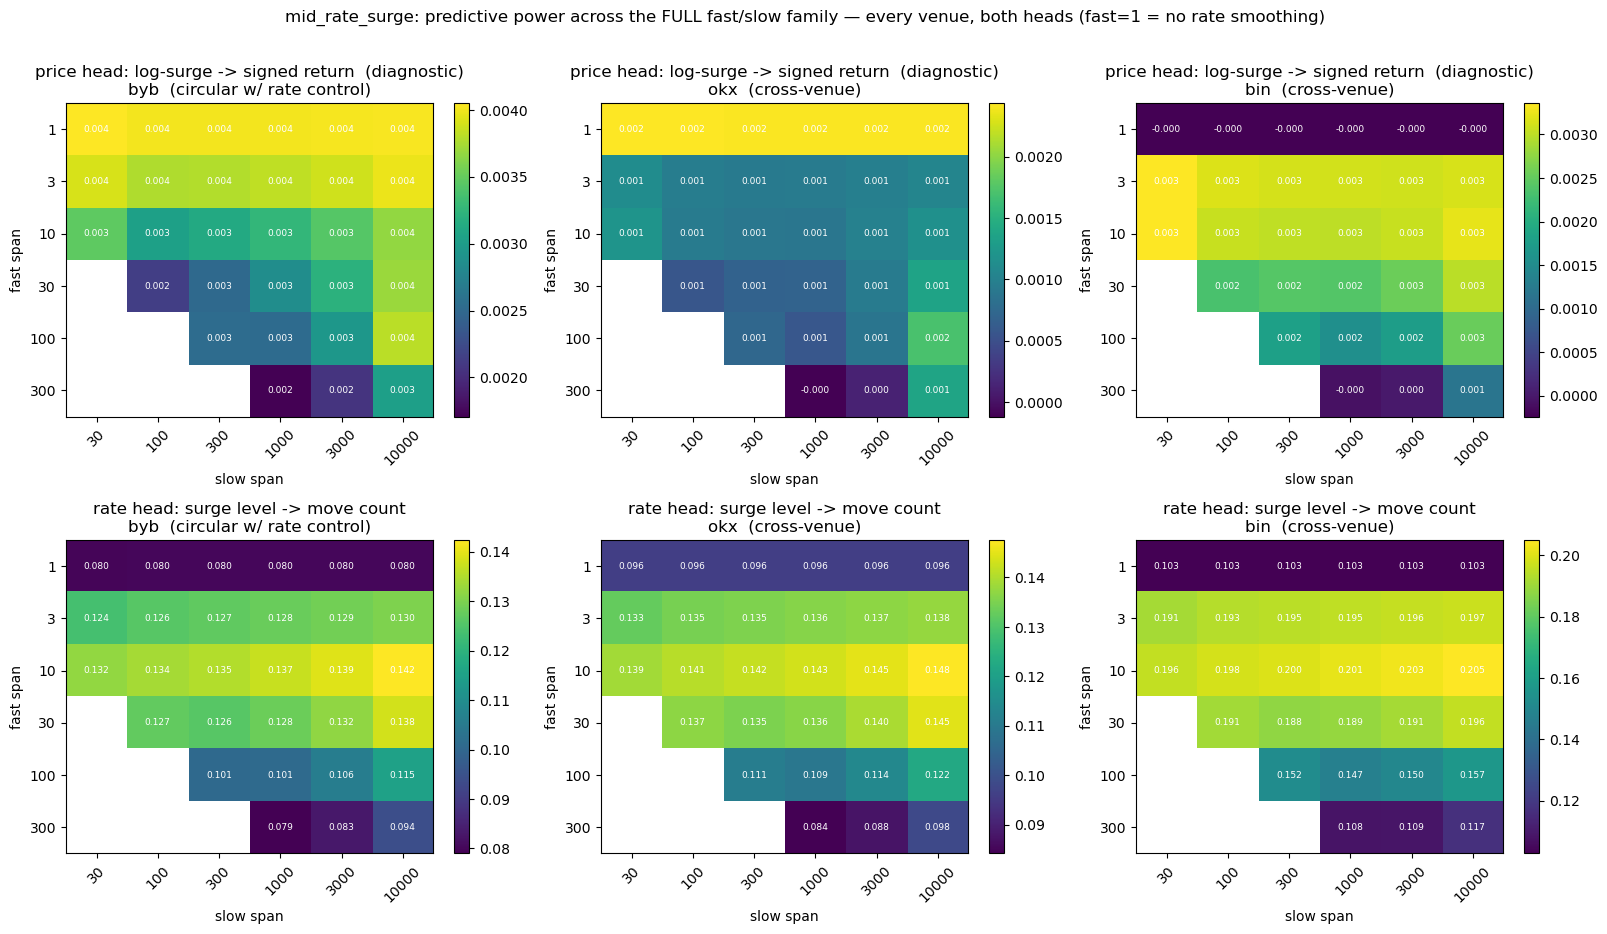

best family member per venue (in-sample pick; re-scored OOS below):
  byb:  price head (fast=1, slow=30) IC=0.004   |  rate head (fast=10, slow=10000) IC=0.142
  okx:  price head (fast=1, slow=30) IC=0.002   |  rate head (fast=10, slow=10000) IC=0.148
  bin:  price head (fast=10, slow=30) IC=0.003   |  rate head (fast=10, slow=10000) IC=0.205


In [5]:
# Sweep the WHOLE family for EVERY venue, BOTH heads. Rate head uses the surge LEVEL (ratio) directly; price head uses log-surge.
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # log-surge -> byb's signed return
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # surge level -> byb's move count (rate_target)
feat_cache = {}
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            s = mid_rate_surge(ex, nf, ns); feat_cache[(ex, nf, ns)] = s
            ls = np.log(np.maximum(s, 1e-12))                              # log surge: symmetric around 0, the natural signed form
            price_grid[ex][i, j] = spearmanr(ls, target).statistic        # price head (diagnostic — expected weak)
            rate_grid[ex][i, j]  = spearmanr(s, rate_target).statistic     # rate head — surge level -> move count

fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 9.2), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: log-surge -> signed return  (diagnostic)"),
                                     (rate_grid,  "rate head: surge level -> move count")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"{head}\n{ex}" + ("  (circular w/ rate control)" if ex == "byb" else "  (cross-venue)"))
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=6.5)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("mid_rate_surge: predictive power across the FULL fast/slow family — every venue, both heads (fast=1 = no rate smoothing)", y=1.01)
fig.tight_layout(); plt.show()

# In-sample pick of the best family member PER head PER venue (used only to choose a time-scale; re-scored OOS by the gates).
def best_member(grid): return np.unravel_index(np.nanargmax(np.abs(grid)), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("best family member per venue (in-sample pick; re-scored OOS below):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    print(f"  {ex}:  price head (fast={FAST[pi]}, slow={SLOW[pj]}) IC={price_grid[ex][pi,pj]:.3f}"
          f"   |  rate head (fast={FAST[ri]}, slow={SLOW[rj]}) IC={rate_grid[ex][ri,rj]:.3f}")

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=1,s=100) IC|best -0.005;  OOS joint +0.005 vs solo +0.004 (Δ+0.001)  ->  one span suffices (no OOS gain)


  okx: best alt (f=1,s=3000) IC|best -0.004;  OOS joint -0.001 vs solo -0.003 (Δ+0.002)  ->  one span suffices (no OOS gain)


  bin: best alt (f=10,s=100) IC|best -0.003;  OOS joint -0.001 vs solo -0.001 (Δ+0.000)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  byb: best alt (f=3,s=1000) IC|best -0.077;  OOS joint +0.123 vs solo +0.126 (Δ-0.003)  ->  one span suffices (no OOS gain)


  okx: best alt (f=3,s=1000) IC|best -0.080;  OOS joint +0.125 vs solo +0.126 (Δ-0.000)  ->  one span suffices (no OOS gain)


  bin: best alt (f=1,s=10000) IC|best +0.088;  OOS joint +0.183 vs solo +0.183 (Δ+0.000)  ->  one span suffices (no OOS gain)


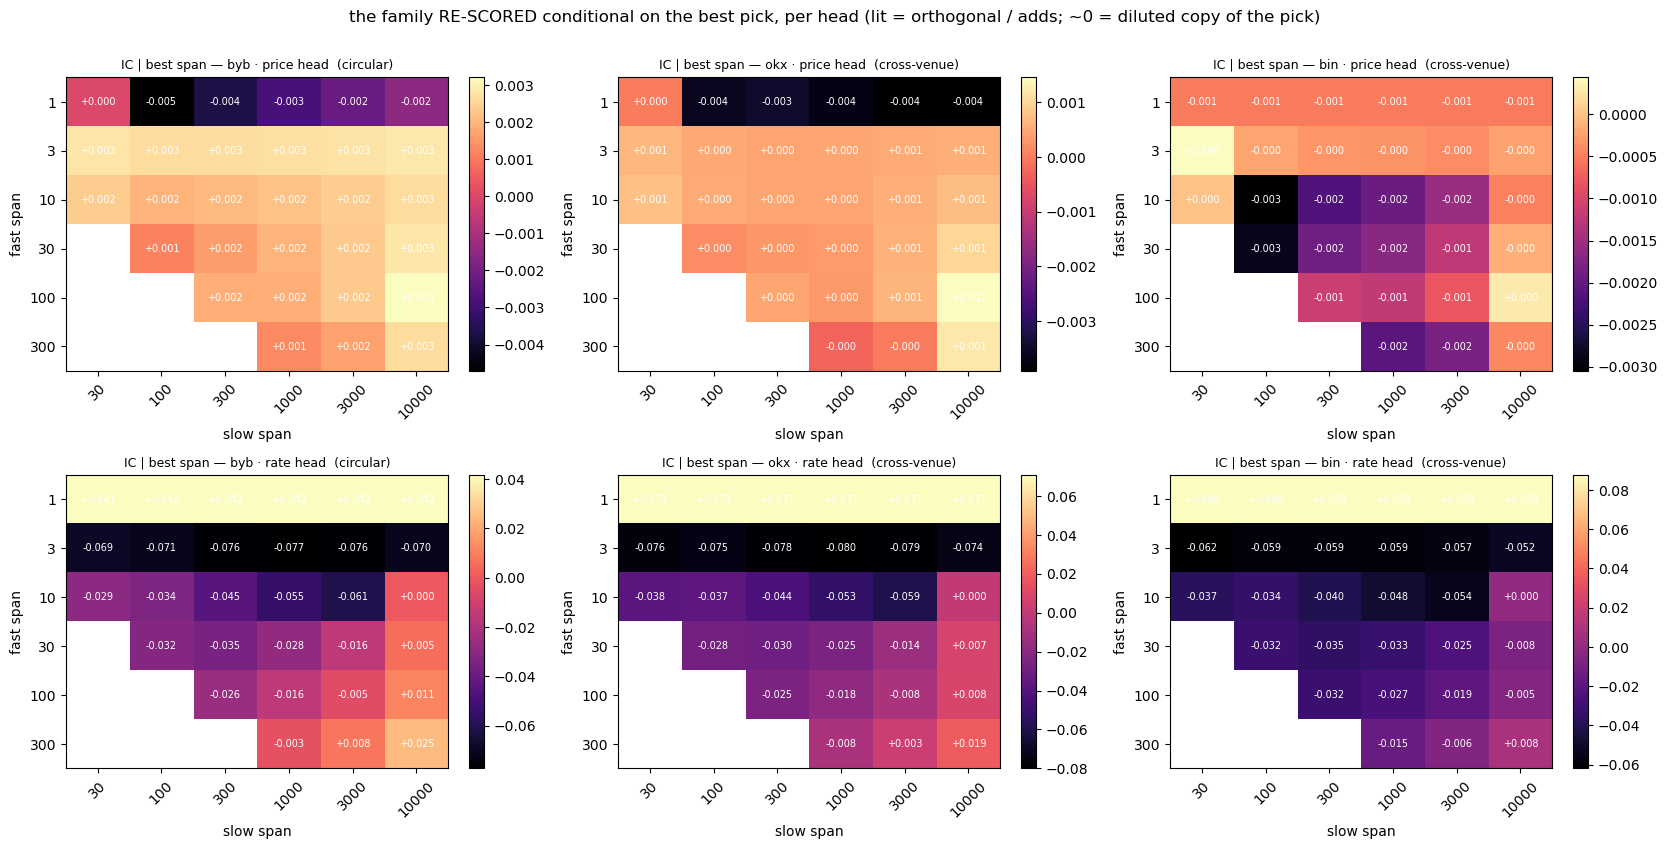

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best (fast,slow) per head by IC; now re-score the WHOLE family as
# partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the span we picked (the
# same partial-IC tool the echo-netting cell uses; control = the chosen span, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a (fast,slow) cell to its scored feature, tgt is the head's target, member is the in-sample pick.
# Rate head reads the surge LEVEL (-> count); price head reads the signed log-surge (-> signed return).
HEADS = [("price head", lambda ex, nf, ns: np.log(np.maximum(mid_rate_surge(ex, nf, ns), 1e-12)), target,      price_member),
         ("rate head",  lambda ex, nf, ns: mid_rate_surge(ex, nf, ns),                            rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(EXCHANGES), figsize=(5.6 * len(EXCHANGES), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(EXCHANGES):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW, rotation=45); ax.set_xlabel("slow span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast span")
        ax.set_title(f"IC | best span — {ex} · {head}" + ("  (circular)" if ex == "byb" else "  (cross-venue)"), fontsize=9)
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** (rate → surge level vs the count target — the feature's home; price → signed
log-surge vs the σ-return target — the diagnostic), **per venue** (byb circular, okx/bin cross-venue). On this
block both find the second span a diluted copy (OOS gain ≈ 0), so one span per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *predictive* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone IC, which is in-sample
(its out-of-sample confirmation comes from the multi-block harness in `tools/oss`).

One caveat for **both heads**: the fast/slow span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic,
since the test folds also informed the span pick. Held-out span selection is deferred to the multi-block
`tools/oss` harness; here the choice is among a small 6×6 fast/slow grid of near-identical neighbours, so
the selection bias is expected to be small (we don't measure it on this single block).

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`** (the rate head
receives the *signed* feature and can learn its magnitude), two leak modes against **both regime coordinates**
(vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want **< ~0.05** for the
signed feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its per-decile *means*
(want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. The vol/rate level is only the
regime *coordinate* here (what we bucket/correlate against), **never** a control. Fail any one of them = a
level in disguise, not a feature. *(For a dimensionless surge **ratio** we expect scale to be steady and
tracking small — but `mid_rate_surge` is a regime descriptor, so this is exactly where a leak could appear;
we measure, never assume.)*

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*,
"signal **over** the controls" is circular for a control's OWN leg. `mid_rate_surge` is a **control** (a
move-rate regime descriptor), so the **byb own leg** is judged on its **standalone** rank-IC (`own=True`),
while the **okx/bin cross-venue legs** stay a **marginal** rank-IC over the regime-invariant controls (the
momenta — **never** the raw levels), `own=False` — the honest lead test. **Mechanical-coupling guard:** the
surge is `rate_fast / rate_slow` and `rate = W/dt`, so the `dt` and the `λ_ev` scale **cancel** — it divides
by **no** yardstick of either target — so there is no spurious ratio coupling to stratify away
(`STRAT_VAR = None`); the standalone branch is therefore a plain mean IC. *Regime-stable* (companion): is the
gain still positive **within** calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the set of per-venue features — symmetric; KEEP ALL venues. We run the RATE head (the feature's home).
# GATE B — predictive signal.  mid_rate_surge is a CONTROL (a move-rate regime descriptor):
#   * byb OWN leg: STANDALONE rank-IC (marginal-over-its-own-rate-control is circular) -> own=True.
#   * okx/bin CROSS-venue legs: MARGINAL rank-IC over the base momenta -> own=False (the honest lead test).
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers
# bind base / FEATURE_KIND / STRAT_VAR / vol_regime). STRAT_VAR=None (the surge divides by no yardstick), so the
# standalone branch is a plain mean IC and the marginal branch is the usual nested-model incremental IC.
surge = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}  # rate-head pick per venue

# rate head, scored against the COUNT target. byb -> standalone; okx/bin -> marginal-over-controls.
byb_standalone = signal_ic([surge["byb"]], own=True,  tgt=rate_target)                 # control's OWN leg: standalone (circular to take a marginal)
cross_joint    = signal_ic([surge["okx"], surge["bin"]], own=False, tgt=rate_target)   # okx+bin cross-venue legs: marginal lead test
cross_each     = {ex: signal_ic([surge[ex]], own=False, tgt=rate_target) for ex in ("okx", "bin")}
cci = wf_marginal_ci([surge["okx"], surge["bin"]], rate_target)   # per-fold spread + block-bootstrap CI for the cross-venue marginal
strat = signal_ic_by_regime([surge["okx"], surge["bin"]], own=False, tgt=rate_target)  # the calm/mid/wild companion (cross-venue)
print(f"byb STANDALONE rate-head IC (circular leg) {byb_standalone:.3f}")
print(f"okx+bin CROSS-VENUE marginal {cross_joint:.3f}  |  per-fold {cci['per_fold']} (positive in {cci['pos']}/{cci['nf']})  "
      f"|  block-bootstrap 90% CI [{cci['ci'][0]}, {cci['ci'][1]}]  (block ~{cci['block_len']} anchors ~{cci['block_s']}s)")

# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) — large |IC| is expected, the opposite of an alpha.
rep = surge["byb"]
print(f"FEATURE_KIND={FEATURE_KIND!r} | byb surge vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (LARGE for a 'control' => it really is a regime descriptor)")

gate_rows = [dict(gate="B · signal (rate)", detail="byb OWN leg — STANDALONE rate-head IC (circular w/ rate_momentum; marginal would be circular)", value=byb_standalone)]
gate_rows += [dict(gate="B · signal (rate)", detail=f"{ex} CROSS-venue — marginal surge->count over the controls; want >~ 0.01", value=cross_each[ex]) for ex in ("okx", "bin")]
gate_rows += [dict(gate="B · signal (rate)", detail="okx+bin cross-venue legs JOINTLY — marginal over the controls", value=cross_joint)]
for ex in EXCHANGES:                                       # GATE A PER VENUE (worst coordinate per check) — the output distribution differs by venue
    a = gate_a(surge[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — signed mean-track, worst coord; want < ~0.05", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate head can learn it), worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable (rate)", detail=f"cross-venue marginal within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(30); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

byb STANDALONE rate-head IC (circular leg) 0.142
okx+bin CROSS-VENUE marginal 0.129  |  per-fold [0.11, 0.146, 0.109, 0.127, 0.154] (positive in 5/5)  |  block-bootstrap 90% CI [0.123, 0.133]  (block ~9479 anchors ~474.0s)


FEATURE_KIND='control' | byb surge vs momenta |IC|: rate 0.308 vol 0.001  (LARGE for a 'control' => it really is a regime descriptor)


gate,detail,value
str,str,f64
"""B · signal (rate)""","""byb OWN leg — STANDALONE rate-head IC (circular w/ rate_momentum; marg…",0.142
"""B · signal (rate)""","""okx CROSS-venue — marginal surge->count over the controls; want >~ 0.0…",0.066
"""B · signal (rate)""","""bin CROSS-venue — marginal surge->count over the controls; want >~ 0.0…",0.111
"""B · signal (rate)""","""okx+bin cross-venue legs JOINTLY — marginal over the controls""",0.129
"""A · regime-inv (byb)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.69
"""A · regime-inv (byb)""","""|IC(feature, vol/rate level)| — signed mean-track, worst coord; want <…",0.146
"""A · regime-inv (byb)""","""|IC(|feature|, vol/rate level)| — magnitude track (the signed-fed rate…",0.146
"""A · regime-inv (byb)""","""non-monotone leak — per-decile-mean dispersion (mean & magnitude), wor…",0.102
"""A · regime-inv (okx)""","""feature scale across vol buckets (max/min) — HARD, want < ~3""",1.72


**Conclusion — read per leg, with the caveat.** `mid_rate_surge` is a **control** (a move-rate regime
descriptor), and the headline splits per leg. The **byb** leg's **standalone** rate-head IC is **+0.142**:
because byb's surge *is* `rate_momentum` (their |IC| overlap is **0.308** — huge, exactly what marks a
control, the opposite of an alpha), a marginal would be circular, and that 0.142 is largely the rate-control
content the model already holds. The **okx/bin** legs are the cross-venue test, and here they **clear it
cleanly**: their **marginal over the controls** is **+0.066 (okx)** and **+0.111 (bin)** on their own,
**+0.129 jointly**, positive in **5/5** OOS folds with a tight block-bootstrap 90% CI **[0.123, 0.133]** —
so another venue's quoting tempo genuinely *leads* byb's move-count beyond what byb's own rate encodes; this
is real new cross-venue information, not a re-parameterisation. **Gate A** is run per venue (a distribution
property), and it is where the **control** nature shows: scale is steady (**1.69 / 1.72 / 1.63**, all ≪ 3),
but the surge **does track the regime level** — mean-track **0.146 / 0.17 / 0.141** (well above the ~0.05
signed bar; the magnitude track equals it since the surge is positive), dispersion **0.10 / 0.09 / 0.05**.
A *clean alpha* would have to pass these; a **regime descriptor is allowed to fail them** (it *is* the rate
regime, so it correlates with `rate_level`/`λ_ev` by construction — that is not a disqualifying "level in
disguise" leak, it is the feature being honest about what it is). The companion confirms the cross-venue
gain is **not** a one-regime artefact — positive and rising across regimes (**0.120 / 0.127 / 0.135** for
calm / mid / wild). We quote the **standalone (byb) / marginal (okx, bin)** number, never a raw IC for the
circular byb leg.

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor−100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

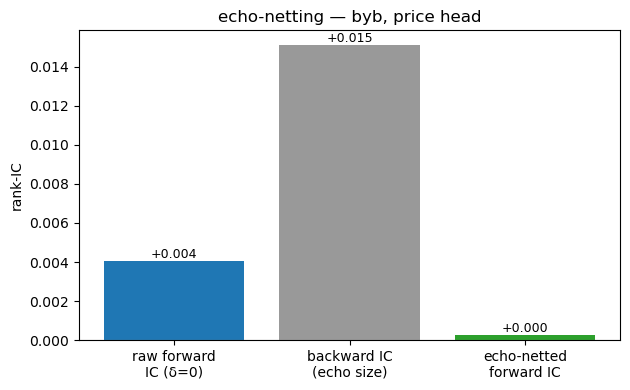

raw forward IC +0.004;  backward (echo) IC +0.015;  echo-netted forward IC +0.000  (the raw->netted shortfall is echo)


In [8]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = EXCHANGES[0]                                    # one exchange to illustrate; every per-venue leg carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = np.log(np.maximum(mid_rate_surge(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]]), 1e-12))   # the chosen price-head feature (signed log-surge)
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (δ=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor−100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100–160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation hides *how* the feature changes the outcome. Group the data by the feature and look
at the real distributions the heads care about, **per venue** (byb's own tempo vs the cross-venue legs):
- **rate head (its home):** how the number of upcoming byb moves grows as each venue's surge ratio grows;
- **price head (diagnostic):** byb's next return for low / middle / high *signed* (log-)surge — expected
  roughly flat, since intensity isn't direction.

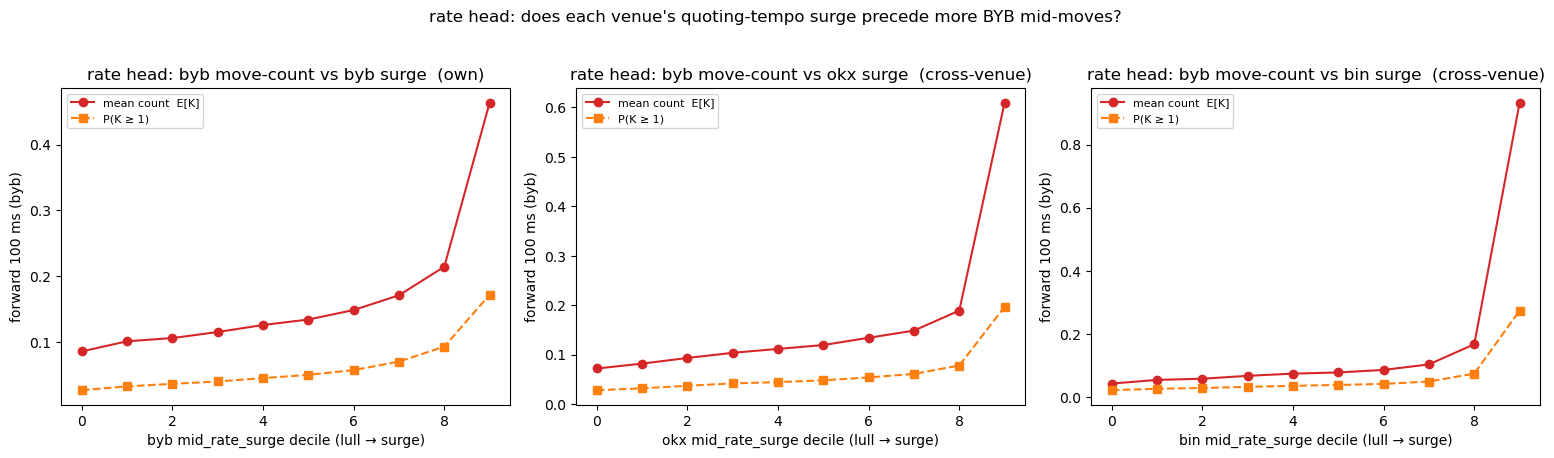

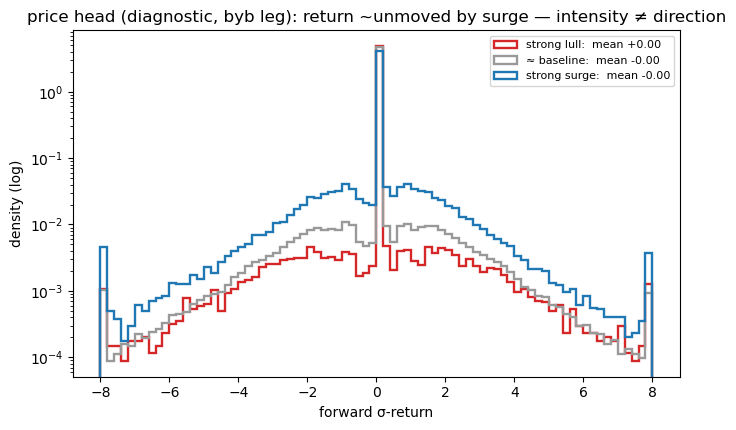

In [9]:
fig, axes = plt.subplots(1, len(EXCHANGES), figsize=(5.2 * len(EXCHANGES), 4.4), squeeze=False)
for col, ex in enumerate(EXCHANGES):
    s = surge[ex]; ax = axes[0][col]
    dec = np.digitize(s, np.nanpercentile(s[np.isfinite(s)], np.arange(10, 100, 10)))
    ax.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
    ax.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
    ax.set_xlabel(f"{ex} mid_rate_surge decile (lull → surge)"); ax.set_ylabel("forward 100 ms (byb)")
    ax.set_title(f"rate head: byb move-count vs {ex} surge" + ("  (own)" if ex == "byb" else "  (cross-venue)")); ax.legend(fontsize=8)
fig.suptitle("rate head: does each venue's quoting-tempo surge precede more BYB mid-moves?", y=1.03)
fig.tight_layout(); plt.show()

# price head (diagnostic): forward σ-return across signed log-surge buckets — expected ~flat — shown for the byb leg
s = surge["byb"]; ls = np.log(np.maximum(s, 1e-12))
fig, axB = plt.subplots(1, 1, figsize=(7, 4.4))
lo, hi = np.nanpercentile(ls, [10, 90])
groups = [("strong lull", ls <= lo, "C3"), ("≈ baseline", (ls > lo) & (ls < hi), "0.6"), ("strong surge", ls >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic, byb leg): return ~unmoved by surge — intensity ≠ direction"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** **Rate head (top row):** on this block all three per-venue panels behave as §1 predicted —
byb's mean move-count `E[K]` and `P(K ≥ 1)` climb monotonically from the lull deciles to the surge deciles
(the intensity story, and the circular control at work), and the **okx/bin** panels climb too, so *another*
venue's surge tracks byb's upcoming move-count — the cross-venue lead the §6 marginals (+0.066 okx, +0.111
bin) quantify, here visible in the raw distribution. **Price head (bottom):** the forward-return
distribution barely shifts across lull / baseline / surge groups (group means ≈ 0) — a surge says *how
many*, not *which way*, confirming this is an intensity feature. So the feature moves the actual outcome
distributions the rate head needs, and the §6/§9 answer — that the cross-venue legs add **new**, fold-stable
marginal over `rate_momentum` — is the distribution made into a number.

## 8. Input shaping for the network

This reshapes the feature for the network's input — roughly centred, unit-scale, no wild outliers — a
*different* step from §2 (there is no regime division here; the feature is already a ratio). A surge
*ratio* is positive and right-skewed, so its **log** is the natural signed, centred form. We feed **every
venue's** log-surge (none privileged). Plot the byb leg (left) and compare candidates by how close to a
clean bell curve they make it (right — points on the diagonal are perfectly normal). Pick the lightest
transform that clears the bar; the same transform applies per venue.

raw ratio: skew=+18.64  excess_kurt=750.7
log surge: skew=-3.72  excess_kurt=30.8  (0 = normal)
  raw ratio (z)          excess_kurt= 750.7   max|·|=117.4
  log surge (z)          excess_kurt=  30.8   max|·|=16.5
  log robust + clip ±4   excess_kurt=   0.8   max|·|=4.0
  rank-Gaussian(log)     excess_kurt=  -0.0   max|·|=5.0


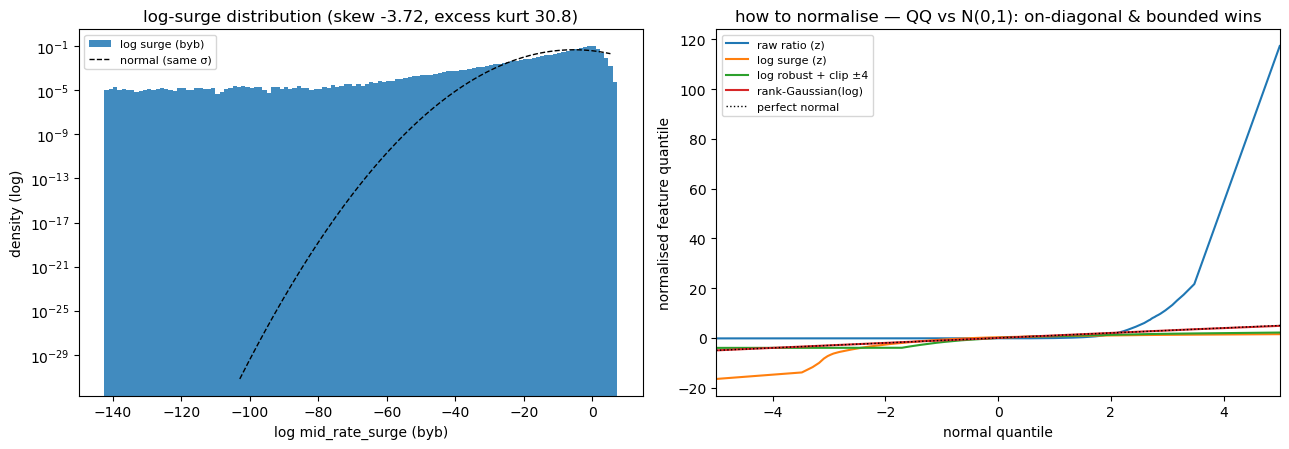

In [10]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = surge["byb"]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                       # log surge: the natural centred, signed form of a ratio
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)); rz = (lf - med) / mad
cand = {"raw ratio (z)": (f - f.mean()) / f.std(),
        "log surge (z)": (lf - lf.mean()) / lf.std(),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian(log)": norm.ppf((rankdata(lf) - 0.5) / len(lf))}
print(f"raw ratio: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}")
print(f"log surge: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(lf, bins=120, density=True, color="C0", alpha=.85, label="log surge (byb)")
xg = np.linspace(np.percentile(lf, 0.05), np.percentile(lf, 99.95), 300)
axA.plot(xg, norm.pdf(xg, lf.mean(), lf.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("log mid_rate_surge (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"log-surge distribution (skew {skew(lf):+.2f}, excess kurt {kurtosis(lf):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(lf) + 1) - 0.5) / len(lf)); sub = np.linspace(0, len(lf) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The raw surge ratio is violently right-skewed and fat-tailed (skew **+18.6**, excess
kurtosis **751**, max|·| **117** as a z-score) — unusable raw. Taking the **log** pulls most of that in
(skew **−3.7**, excess kurtosis **31**), but a plain z-score of the log still leaves a heavy left tail
(max|·| **16.5**), so it does **not** clear the "no wild outliers" bar on its own. The lightest transform
that *does* is **log → robust-z → clip ±4** (excess kurtosis **0.8**, max|·| **4.0**) — that is what to feed
the network. The heavier rank-Gaussian flattens the tail to a clean bell (excess kurtosis ≈ 0) but throws
information away. So: feed `log(mid_rate_surge)` per venue, robust-standardised and clipped — and remember
the model *already* has `rate_momentum`, so the **byb** leg enters as a near-duplicate rate-tempo input the
model can down-weight, while the **okx/bin** legs enter as the genuinely cross-venue inputs.

## 9. When is per-exchange worth it? — short vs long lookback

`mid_rate_surge` is a **poolable** per-venue feature (one surge per venue), so the template's real
per-exchange question *does* apply here: keep them **per-exchange**, collapse to a **single** venue, or
**pool** them? The answer depends on the time-scale — so we sweep the **slow** span (the lookback) and
compare the three, walk-forward, on the rate head. (This is a genuine computation, not an illustrative
note: a per-venue surge *can* be pooled, unlike the template's cross-venue gap.)

**The mechanism, and what to expect.** The cross-venue edge is a **quoting-tempo lead/lag** — one venue
repricing a beat before another. At **short** lookbacks the venues genuinely differ (who is accelerating
first), so the per-venue set carries distinct cross-venue lead/lag and should beat a single venue; at
**long** lookbacks every venue's smoothed tempo converges to the same slow drift, so a **single** venue
already says what the rest do and the extra legs are redundant. We compute, at each slow span (fast leg
fixed short): the **per-exchange** marginal (all three legs), the **single best** venue's marginal, and
the **pooled** (mean log-surge across venues) marginal — each over the controls, walk-forward.

In [11]:
# Sweep the lookback (slow span); fast leg fixed short so the rate stays responsive. Compare per-exchange / single / pooled.
FAST_FIX = 3                                                            # a short, responsive fast leg held fixed across the sweep
look_rows = []
for ns in SLOW:
    if ns <= FAST_FIX: continue
    legs = {ex: mid_rate_surge(ex, FAST_FIX, ns) for ex in EXCHANGES}   # one surge per venue at this lookback
    per_ex  = round(wf_ic(base + list(legs.values()), rate_target) - wf_ic(base, rate_target), 3)   # all three legs
    singles = {ex: round(wf_ic(base + [legs[ex]], rate_target) - wf_ic(base, rate_target), 3) for ex in EXCHANGES}
    best_ex = max(singles, key=singles.get); single = singles[best_ex]
    logs    = [np.log(np.maximum(legs[ex], 1e-12)) for ex in EXCHANGES]
    pooled  = round(wf_ic(base + [np.nanmean(np.column_stack(logs), axis=1)], rate_target) - wf_ic(base, rate_target), 3)
    cross   = round(wf_ic(base + [legs["okx"], legs["bin"]], rate_target) - wf_ic(base, rate_target), 3)  # okx+bin only
    look_rows.append(dict(slow_span=ns, per_exchange=per_ex, best_single=f"{single} ({best_ex})",
                          pooled=pooled, cross_venue_only=cross))
look_df = pl.DataFrame(look_rows)
print("rate-head marginal over controls, by lookback (slow span); fast leg fixed =", FAST_FIX)
print("per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)")
look_df

rate-head marginal over controls, by lookback (slow span); fast leg fixed = 3
per_exchange = all 3 legs | best_single = best one venue | pooled = mean log-surge | cross_venue_only = okx+bin (no byb)


slow_span,per_exchange,best_single,pooled,cross_venue_only
i64,f64,str,f64,f64
30,0.108,"""0.066 (bin)""",0.099,0.095
100,0.104,"""0.059 (bin)""",0.104,0.087
300,0.104,"""0.058 (bin)""",0.105,0.087
1000,0.104,"""0.057 (bin)""",0.105,0.088
3000,0.103,"""0.056 (bin)""",0.105,0.088
10000,0.104,"""0.055 (bin)""",0.105,0.088


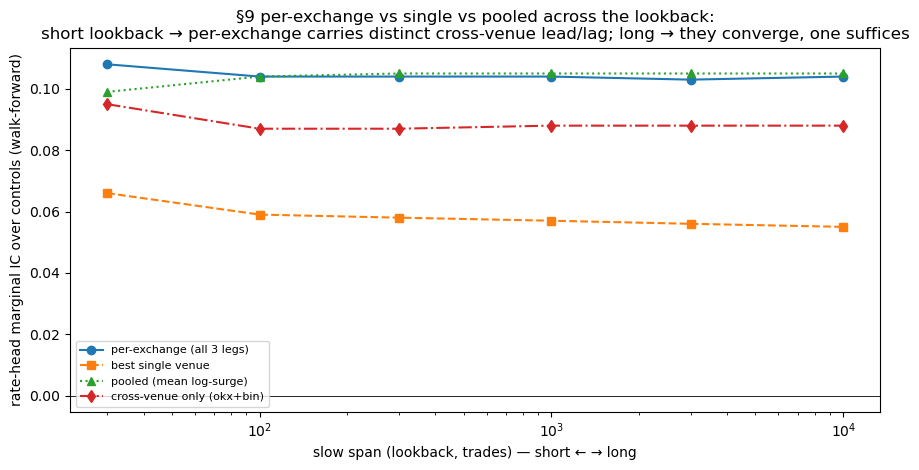

In [12]:
# Plot the per-exchange vs single vs pooled curves across the lookback sweep — the §9 cross-over picture.
xs = [r["slow_span"] for r in look_rows]
per = [r["per_exchange"] for r in look_rows]
sin = [float(r["best_single"].split()[0]) for r in look_rows]
poo = [r["pooled"] for r in look_rows]
crs = [r["cross_venue_only"] for r in look_rows]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(xs, per, "o-", label="per-exchange (all 3 legs)", color="C0")
ax.plot(xs, sin, "s--", label="best single venue", color="C1")
ax.plot(xs, poo, "^:", label="pooled (mean log-surge)", color="C2")
ax.plot(xs, crs, "d-.", label="cross-venue only (okx+bin)", color="C3")
ax.set_xscale("log"); ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("slow span (lookback, trades) — short ← → long"); ax.set_ylabel("rate-head marginal IC over controls (walk-forward)")
ax.set_title("§9 per-exchange vs single vs pooled across the lookback:\nshort lookback → per-exchange carries distinct cross-venue lead/lag; long → they converge, one suffices")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**Conclusion — read the table and curves above.** The §9 picture on this block is **per-exchange wins at
every lookback** — it does **not** show the convergence the template's gap feature does. The per-exchange
set (all three legs) sits at **~0.104** across the whole slow-span sweep, far above the **best single
venue** (always **bin**, only **~0.055–0.066**) — and it stays there at the longest lookback (10000: 0.104
vs 0.055), so the venues keep contributing distinct information rather than collapsing to one. **Pooling**
(mean log-surge) tracks per-exchange closely (**~0.10–0.105**) — for this feature pooling neither helps nor
hurts much, but it is not worse, unlike the template's gap. The **cross-venue-only** curve (okx+bin, no byb)
sits **above 0 at every lookback** (**~0.087–0.095**), so another venue's tempo genuinely leads byb's
move-count over and above byb's own rate — the cross-venue legs carry real marginal value, the byb circular
leg is *not* doing all the work. The honest verdict read straight off these numbers: **keep all three venues
per-exchange at every lookback** — the cross-venue lead/lag here is persistent, not a short-lookback-only
effect.

## 10. The verdict, and what it takes to ship

**Keep the per-venue family — feed every venue's *signed* log-surge to the rate head — but label each leg
for what it is:**
- **Rate head (intensity):** `mid_rate_surge` is the natural input — a fast rate over a slow rate; the
  surge ratio predicts byb's move-count (§6/§7). Sweep the (fast, slow) family **per venue** and let the
  data pick (§6 heat-maps), then the §6 conditional-IC re-score asks whether a **second** time-scale adds
  over the pick — on this block it doesn't (the most-orthogonal alternative span carries no walk-forward
  joint-vs-solo gain over the chosen one), so **one span per head per venue suffices**. Keep all three
  venues per-exchange at **every** lookback (§9) — the cross-venue lead/lag is persistent here, **not** a
  short-lookback-only effect that converges away (§9: per-exchange ~0.104 vs best single ~0.055 even at the
  longest lookback, slow=10000).
- **Price head (direction):** ≈0 — don't feed it expecting direction; it's an intensity feature.
- **Feature form:** `log(mid_rate_surge)` per venue, robust-z, clip ±4 (§8). **No yardstick division** —
  it's already a dimensionless ratio (and so `STRAT_VAR = None`: it shares no denominator with either target).

**The control-circularity verdict, PER LEG (the headline, on this block).** `mid_rate_surge` is
`FEATURE_KIND="control"` — a move-rate regime descriptor. byb's mid-update rate **is** `λ_ev`, and a
fast/slow ratio of it **is** `rate_momentum` — so the **byb** leg is *not* new orthogonal information: its
standalone rate-head IC is **+0.142** but its |IC| overlap with `rate_momentum` is **0.308** — most of it is
rate-control content the model already holds. **Keep it only as a span-tuned twin of the rate control, never
as fresh signal.** The **okx** and **bin** legs are **not** circular — they are other venues' tempo — and on
this block they **clear the bar**: marginal over the controls **+0.066 (okx)** and **+0.111 (bin)**,
**+0.129 jointly**, positive in **5/5** OOS folds (CI **[0.123, 0.133]**) — so another venue's quoting tempo
genuinely **leads** byb's move-count. §9 confirms the per-exchange set beats the best single venue (~0.104 vs
~0.06) at **every** lookback, so keep all three legs per-exchange. Always quote the **standalone (byb) /
marginal-over-controls (okx, bin)** number, never a raw IC for the circular leg.

**The echo-netting verdict (is it real prediction, or an echo?).** A raw forward IC can be inflated by the
move already underway at the anchor, so the honest "is this genuine forward prediction?" number is the
**echo-netted (partial) forward IC** — the feature against the forward outcome controlling for the trailing
`[anchor−100 ms, anchor]` outcome. This is acute for the **byb** circular leg, whose forward IC is largely a
re-report of the move-rate already underway; netting out the trailing move shows what survives. For the
**okx/bin cross-venue** legs the data is recorded with **production timing** (`rx_time` is exactly the live
cadence), so a freshness lead is **genuine, exploitable edge** — there is no recording artifact to coarsen
away, and we do **not** match the foreign feed to byb's cadence. **Quote the echo-netted number** for the
circular leg in any decision to keep or drop it.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, per venue, matching this analysis version (§4, done)
- [ ] the §4 parity check and tests, passing **bit-exact for every per-venue leg**
- [ ] the §6 standalone (byb) / marginal-over-`rate_momentum` (okx,bin) recorded **per leg**, with the byb-circular / okx-bin-cross call made
- [ ] the §6 conditional-IC second-span test recorded **per head per leg** — whether a second time-scale adds OOS over the pick (joint-vs-solo `wf_ic`), or one span suffices
- [ ] the echo-netting recorded — the **echo-netted (partial) forward IC** vs the raw/backward IC, with the netted number cited for the circular byb leg
- [ ] the §9 per-exchange-vs-single cross-over recorded (where per-exchange stops paying)
- [ ] the chosen rate-head time-scale per venue written down, with the yardstick span
- [ ] the data quirks handled (bad zero-price prints; byb/okx mid = merged_levels, bin = front_levels; one decay per timestamp)